In [51]:
import so
import pandas as pd

In [52]:
q_daily = so.load_data('data/csv/final/q_daily.csv', date_column='date')
a_daily = so.load_data('data/csv/final/a_daily.csv', date_column='date')
results = so.read_results('qa.csv')

In [53]:
filenames = ['android_c.csv', 'csharp_c.csv', 'java_c.csv', 'other_c.csv', 'python_c.csv', 'r_c.csv', 'web_c.csv']
tags = ['android', 'c#', 'java', 'other', 'python', 'r', 'web']
tag_dfs = {}
for tag, filename in zip(tags, filenames):
    print(f'Loading: {tag}')
    tag_daily = so.load_data(f'data/csv/tags/{filename[:-4]}_daily.csv', date_column='date')
    tag_dfs[tag] = tag_daily
tag_results = so.read_results('tags.csv')

Loading: android
Loading: c#
Loading: java
Loading: other
Loading: python
Loading: r
Loading: web


In [54]:
dfs = {'questions': q_daily, 'answers': a_daily}
targets = ['log_lc', 'log_loc', 'Medium']
dfs = dfs | tag_dfs
results = results | tag_results
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc'], 'java': targets, 'python': targets, 'web': targets}

In [55]:
events = {
    #'ChatGPT Updates 1': '2022-12-15', 
    #'ChatGPT Updates 2': '2023-01-09',
    #'ChatGPT Updates 3': '2023-01-30',
    'ChatGPT Plus': '2023-02-09',
    #'ChatGPT Updates 4': '2023-01-13',
    'ChatGPT 4': '2023-03-14',
    #'ChatGPT Updates 5': '2023-03-23',
    #'ChatGPT Updates 6': '2023-05-03',
    #'ChatGPT Updates 7': '2023-05-12',
    #'ChatGPT iOS App': '2023-05-24',
    #'SO Collectives': '2021-06-23',
    #'SO HTML Update 1': '2021-07-11',
    #'SO HTML Update 2': '2021-07-30',
    #'SO Accepted Answer': '2021-09-08',
    #'SO Post Summary 1': '2022-01-24',
    #'SO Post Summary 2': '2022-02-08',
    #'SO Post Summary 3': '2022-05-10',
    #'SO Student Ambassador': '2022-08-29',
    #'SO Bookmarks': '2022-10-06',
    #'SO Inbox': '2022-11-29',
    'SO ChatGPT Ban': '2022-12-05',
    'SO Plagiarism Flag': '2023-03-22',
    #'SO Design Update': '2024-05-21',
    #'Python Update 1': '2021-10-04',
    'Python Update': '2022-10-24',
    #'Pandas Update 1': '2021-07-02',
    #'Pandas Update 2': '2022-01-22',
    #'Pandas Update 3': '2022-09-19',
    #'Pandas Update 4': '2023-04-03',
    #'JS Update 1': '2021-06-24',
    'JS Update': '2022-06-24',
    #'React Update': '2022-03-29',
    #'Java Update 1': '2021-09-14',
    #'Java Update': '2022-03-22',
    'Java Update': '2022-09-20',
    #'Java Update 4': '2023-03-21'
    }

In [56]:
ev = pd.to_datetime(pd.Series(events.values())).dt.normalize()

for _, df in dfs.items():
    df['E'] = 0
    k_td = pd.Timedelta(days=7)
    for i, d in enumerate(ev):
        mask = df['date'].between(d - k_td, d + k_td)
        df.loc[mask, 'E'] = i

In [57]:
k_td = pd.Timedelta(days=14)
mask = dfs['python']['date'].between(ev[5] - k_td, ev[5] + k_td)
q_daily[mask]

,date,line_count_n,line_count_sum,line_count_bar,line_count_ss,log_lc_n,log_lc_sum,log_lc_bar,log_lc_ss,ViewCount_n,...,ViewCount_ss,Score_n,Score_sum,Score_bar,Score_ss,T,P,W,D,E
375,2022-06-10,3971,152055.0,38.291362,17054929.0,3971,12098.981170,3.046835,41896.953471,3971,...,2.726533e+10,3971,2386,0.600856,25834,1,0,23,4,0
376,2022-06-11,2375,102378.0,43.106526,11807378.0,2375,7590.263313,3.195900,27185.218258,2375,...,1.316822e+10,2375,1363,0.573895,10221,1,0,23,5,0
377,2022-06-12,2433,109733.0,45.101932,14852927.0,2433,7712.376814,3.169904,27734.188019,2433,...,9.118527e+09,2433,1162,0.477600,7540,1,0,23,6,0
378,2022-06-13,4165,158226.0,37.989436,16919466.0,4165,12673.313304,3.042812,43831.448136,4165,...,5.534299e+10,4165,2356,0.565666,26698,1,0,24,0,0
379,2022-06-14,4483,169788.0,37.873745,17491960.0,4483,13567.944267,3.026532,46925.474259,4483,...,1.992606e+10,4483,2606,0.581307,14540,1,0,24,1,0
380,2022-06-15,4464,173090.0,38.774642,18157668.0,4464,13630.379071,3.053400,47486.271864,4464,...,4.817541e+10,4464,2758,0.617832,58192,1,0,24,2,0
381,2022-06-16,4369,168905.0,38.659876,18338593.0,4369,13376.057954,3.061583,46572.450469,4369,...,1.368292e+10,4369,2531,0.579309,12507,1,0,24,3,0
382,2022-06-17,3862,152200.0,39.409632,18334862.0,3862,11826.640727,3.062310,41218.998633,3862,...,1.655566e+10,3862,2030,0.525634,11808,1,0,24,4,5
383,2022-06-18,2281,98899.0,43.357738,13444855.0,2281,7180.700798,3.148049,25594.973363,2281,...,1.421016e+11,2281,1098,0.481368,7082,1,0,24,5,5
384,2022-06-19,2357,106257.0,45.081459,14008553.0,2357,7589.406760,3.219943,27372.969795,2357,...,7.359321e+09,2357,1271,0.539245,7307,1,0,24,6,5


In [58]:
start_dates = {}
masks = {}
eresults = {}

for type, df in dfs.items():
    print(f'Masks: {type}')
    start_dates[type], masks[type] = so.rolling_window_masks(df, data_column='date', normalized=True, window_days=30)    

for type, outcome_list in outcomes.items():
    for outcome in outcome_list:
        print('*******************************')
        print(f'Observed: {type} - {outcome}')
        print('Streak: ', so.effect_streak(results[(type, outcome)]))
        print('Max: ', so.max_rolling_mean(results[(type, outcome)]))
        print('AUC: ', so.auc(results[(type, outcome)]) / len(results[(type, outcome)]))

        X, y = so.did_design_matrix(f'{outcome}_bar', dfs[type], events=True)
        res = so.did_wls(dfs[type], X, y, masks[type], start_dates[type], outcome)
        eresults[(type, outcome)] = res

        print('------------------------------')
        print(f'Events: {type} - {outcome}')
        print('Streak: ', so.effect_streak(res))
        print('Max: ', so.max_rolling_mean(res))
        print('AUC: ', so.auc(res) / len(res))

Masks: questions
Masks: answers
Masks: android
Masks: c#
Masks: java
Masks: other
Masks: python
Masks: r
Masks: web
*******************************
Observed: questions - log_lc
Streak:  1.0
Max:  0.07508304697799573
AUC:  0.06282949738442184
------------------------------
Events: questions - log_lc
Streak:  1.0
Max:  0.07345735636905361
AUC:  0.06176933448254804
*******************************
Observed: answers - log_lc
Streak:  1.0
Max:  0.04052282424492403
AUC:  0.028973673337511476
------------------------------
Events: answers - log_lc
Streak:  1.0
Max:  0.03984608545502488
AUC:  0.029501118372072952
*******************************
Observed: java - log_lc
Streak:  0.6490066225165563
Max:  0.10410095982571863
AUC:  0.07179517687802416
------------------------------
Events: java - log_lc
Streak:  0.4105960264900662
Max:  0.10866063968290357
AUC:  0.07158162291482949
*******************************
Observed: java - log_loc
Streak:  0.4105960264900662
Max:  0.08331769272943942
AUC:  0.

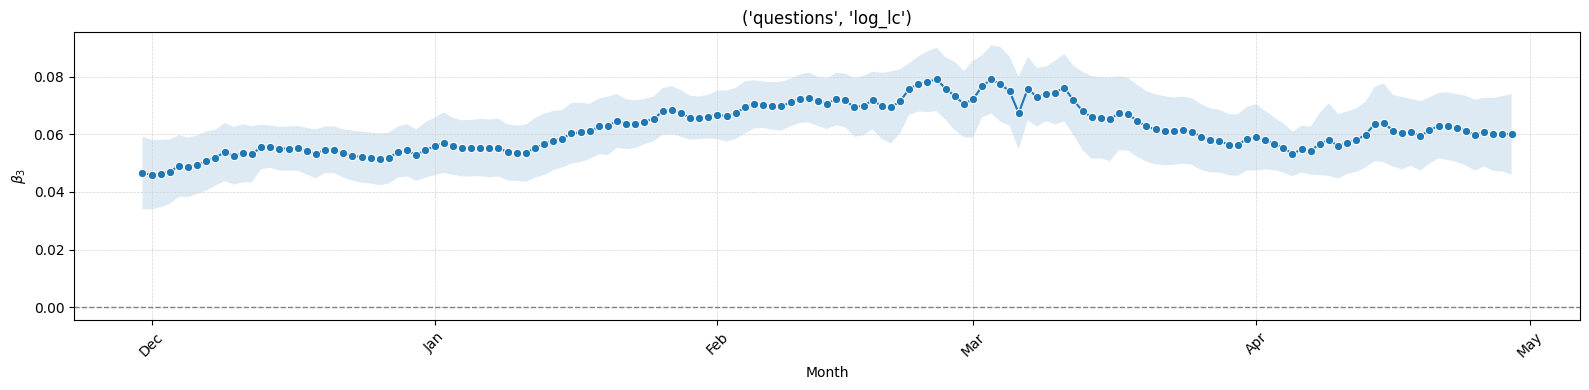

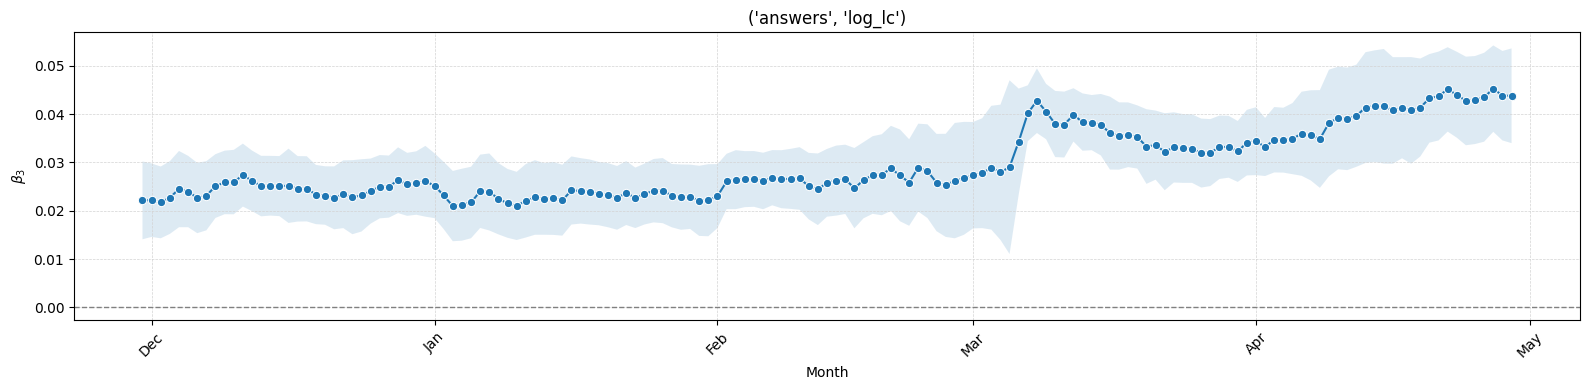

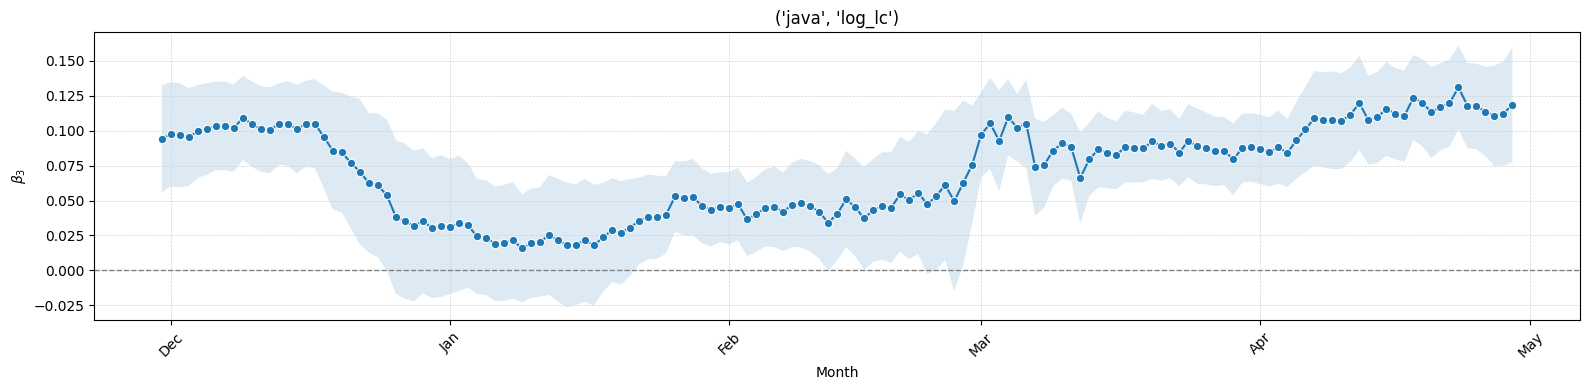

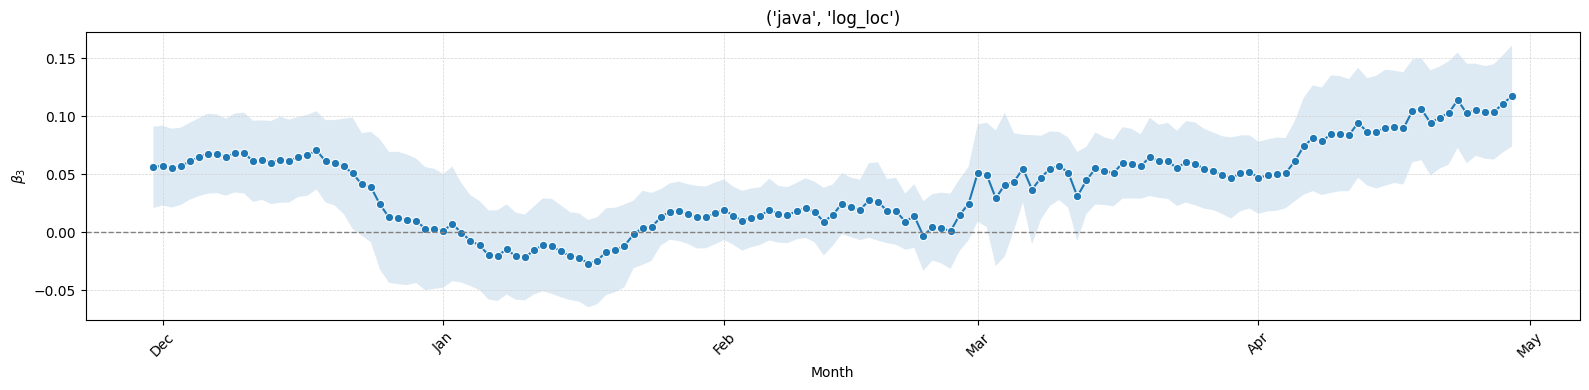

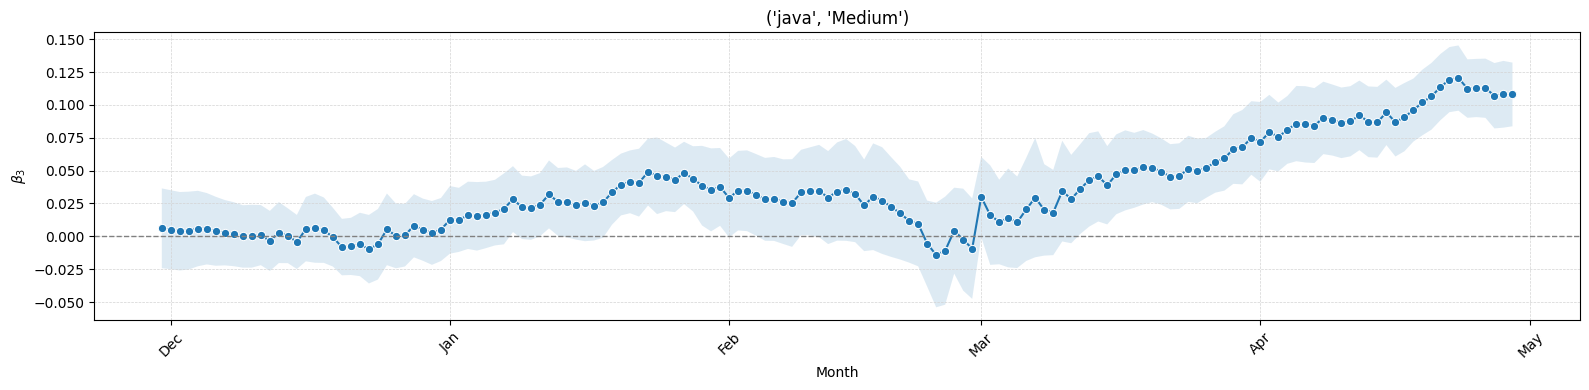

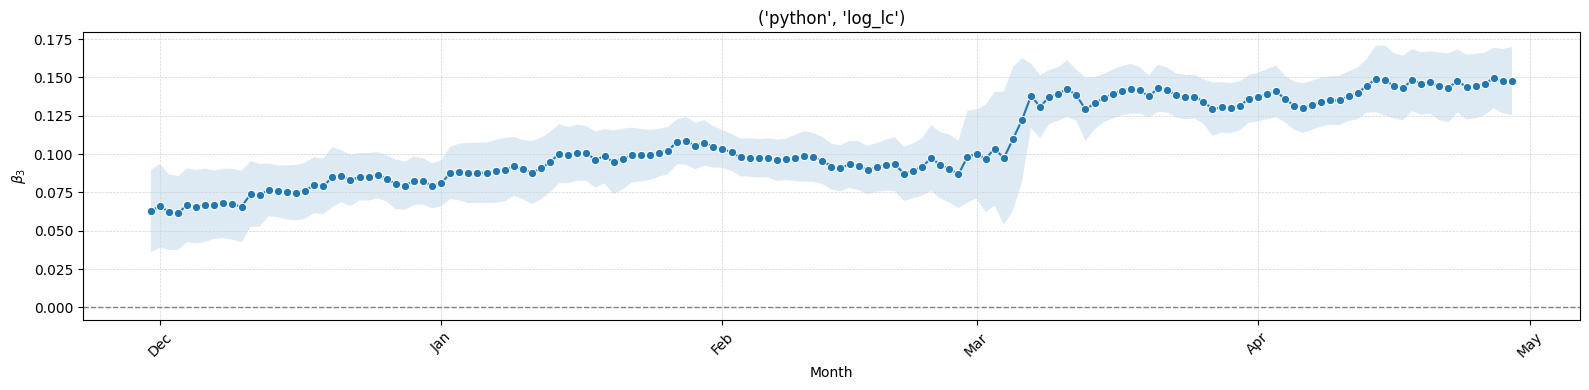

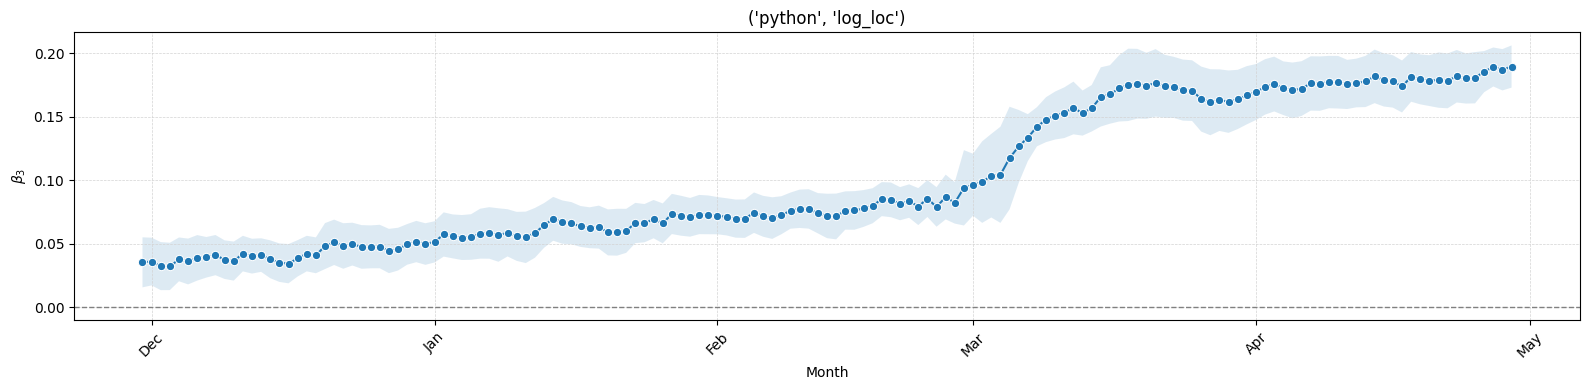

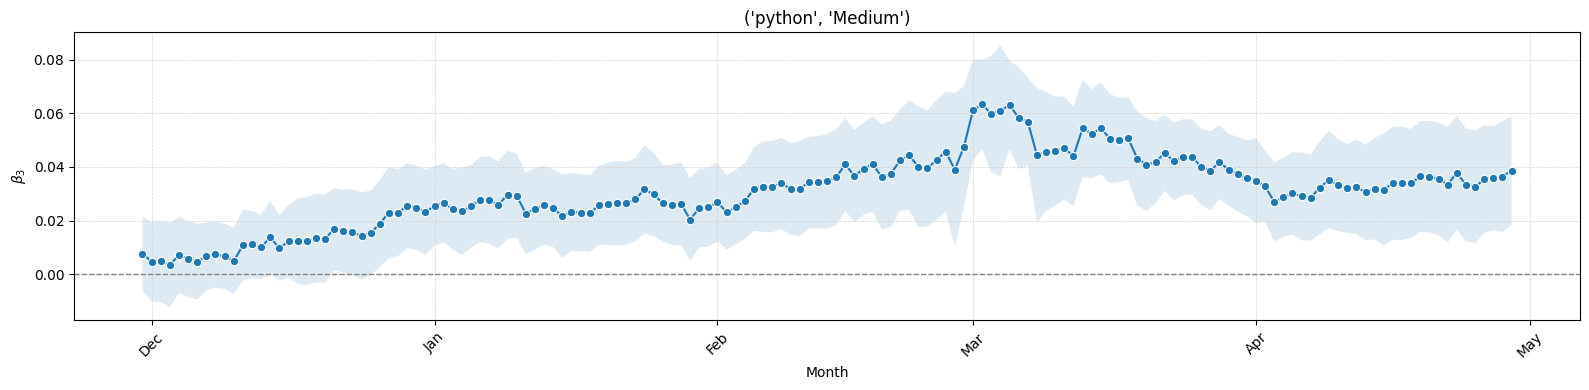

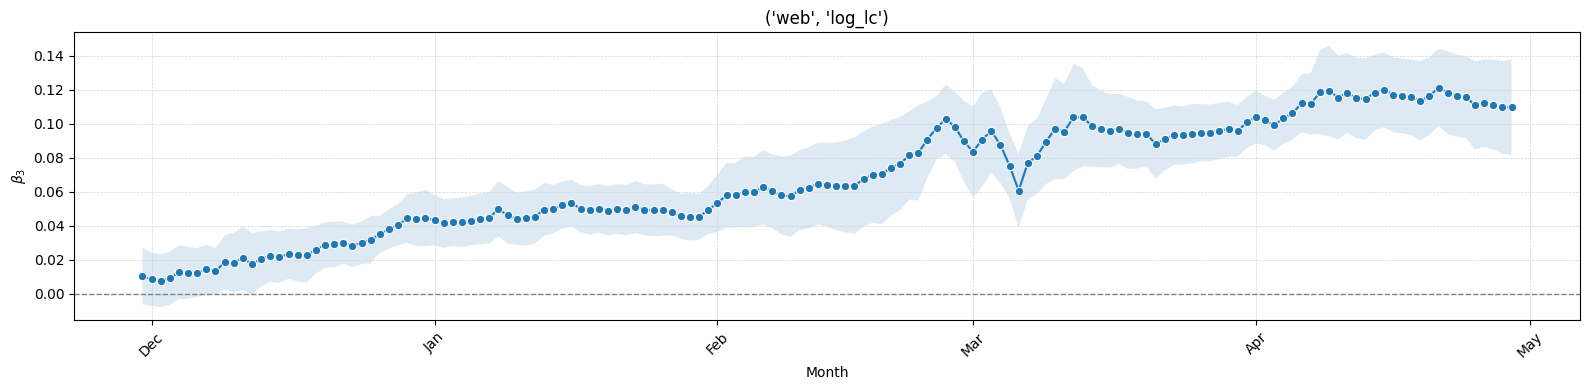

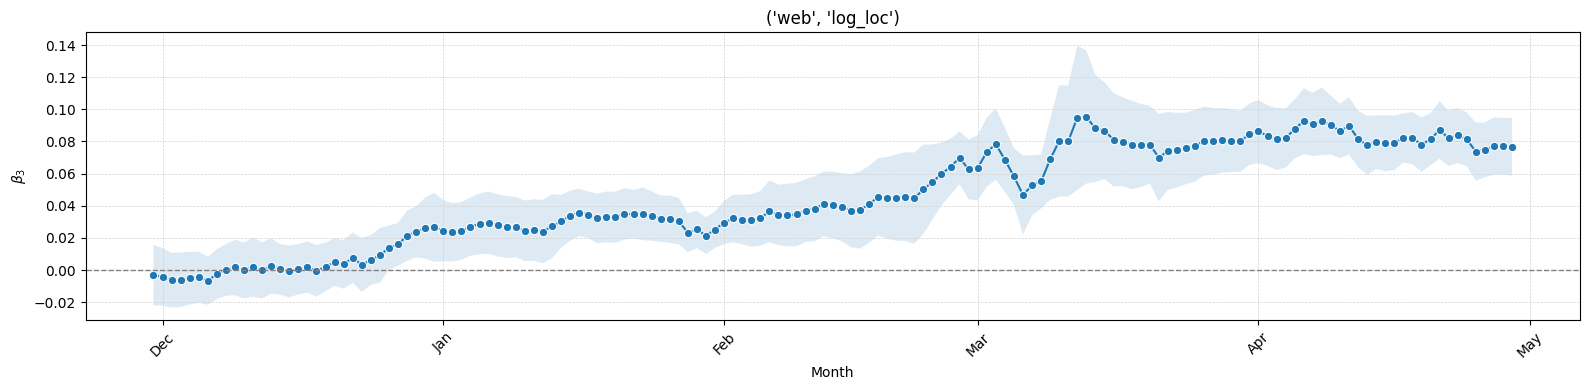

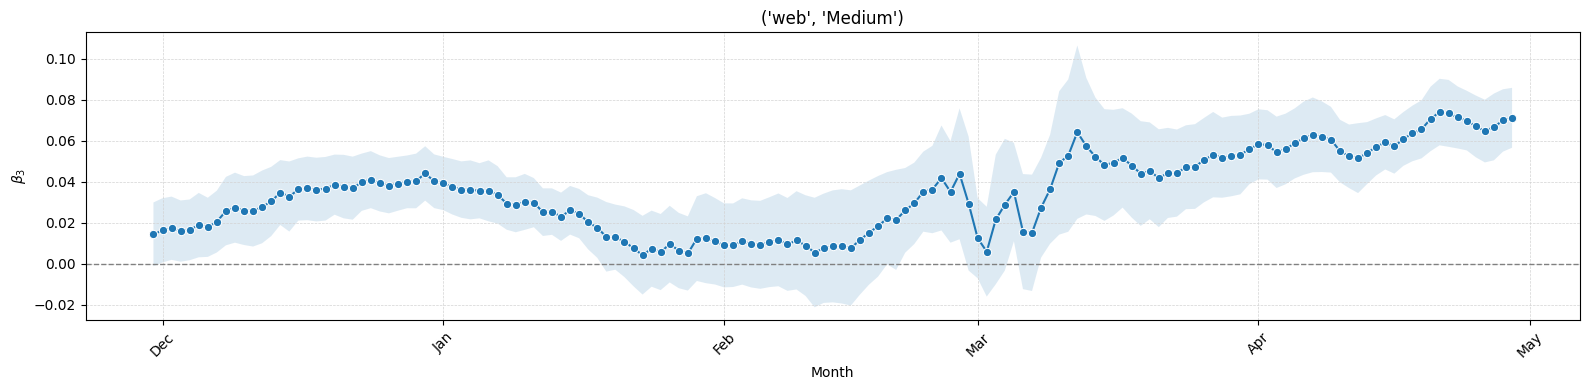

In [59]:
for key, df_res in eresults.items():
    so.plot_did(df_res, key, 'temp/temp.pdf')